<h1 align="center">Join Submission and Numeric Data Sets to Find Numeric Facts</h1>

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
# Set the format for floating point numbers to show no decimal places
pd.set_option('display.float_format', lambda x: '%.0f' % x)
# To display plots inline within the notebook
%matplotlib inline
# Set the notebook width to 100%
display(HTML("<style>.container { width:100% !important; }</style>"))

### Read Submission Data Set for 2022 Q1 from [Financial Statement Data Sets](https://www.sec.gov/dera/data/financial-statement-data-sets)

In [2]:
# Setting low_memory parameter to False to prevent mixed type inference and default_na parameter to False so that empty strings are not parsed as NaN.
submissionsQ1 = pd.read_csv('data/2022q1/sub.txt', sep='\t', low_memory=False, keep_default_na=False)

### Look at the contents of submissionsQ1 dataframe. We have 7,237 submissions. Each row has 36 columns.

In [3]:
submissionsQ1

,adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
0,0000002178-22-000033,2178,"ADAMS RESOURCES & ENERGY, INC.",5172,US,TX,HOUSTON,77027,17 S. BRIAR HOLLOW LN.,,...,20211231,2021,FY,20220309,2022-03-09 16:17:00.0,0,1,ae-20211231_htm.xml,1,
1,0000002488-22-000016,2488,ADVANCED MICRO DEVICES INC,3674,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,,...,20211231,2021,FY,20220203,2022-02-03 17:23:00.0,0,1,amd-20211225_htm.xml,1,
2,0000002969-22-000010,2969,AIR PRODUCTS & CHEMICALS INC /DE/,2810,US,PA,ALLENTOWN,18106-5500,1940 AIR PRODUCTS BLVD.,,...,20211231,2022,Q1,20220204,2022-02-04 10:32:00.0,0,1,apd-20211231_htm.xml,1,
3,0000003499-22-000004,3499,ALEXANDERS INC,6798,US,NJ,PARAMUS,07652,210 ROUTE 4 EAST,,...,20211231,2021,FY,20220214,2022-02-14 08:19:00.0,0,1,alx-20211231_htm.xml,1,
4,0000003570-22-000024,3570,CHENIERE ENERGY INC,4924,US,TX,HOUSTON,77002,700 MILAM ST.,SUITE 1900,...,20211231,2021,FY,20220224,2022-02-23 21:37:00.0,0,1,lng-20211231_htm.xml,1,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7232,0001902733-22-000013,1902733,"NCINO, INC.",7372,US,NC,WILMINGTON,28405,6770 PARKER FARM DRIVE,,...,20220131,2021,FY,20220331,2022-03-31 17:26:00.0,0,1,ncno-20220131_htm.xml,1,
7233,0001903596-22-000067,1853825,THUMZUP MEDIA CORP,7374,US,NV,CARSON CITY,89701,711 S CARSON STREEET,SUITE 4,...,20211231,2021,FY,20220317,2022-03-17 16:23:00.0,0,1,sfs030122tmc10k_htm.xml,1,
7234,0001903596-22-000075,1414767,NETCAPITAL INC.,6199,US,MA,BOSTON,02111,1 LINCOLN STREET,,...,20220131,2022,Q3,20220318,2022-03-18 13:00:00.0,0,1,sfs10qncpl031622_htm.xml,1,
7235,0001903596-22-000108,1087022,ALR TECHNOLOGIES INC.,3669,US,VA,RICHMOND,23225,7400 BEAUFONT SPRINGS DRIVE,SUITE 300,...,20211231,2021,FY,20220330,2022-03-30 13:01:00.0,0,1,sfsalr10k032222_htm.xml,1,


### Read Numeric Data Set for 2022 Q1 from [Financial Statement Data Sets](https://www.sec.gov/dera/data/financial-statement-data-sets)

In [4]:
# Setting low_memory parameter to False to prevent mixed type inference
numericFactsQ1 = pd.read_csv('data/2022q1/num.txt', sep='\t', low_memory=False)

### Look at contents of numericFactsQ1 dataframe. We have 3,264,632 numeric facts. Each row has 10 columns.

In [5]:
numericFactsQ1

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
0,0001126975-22-000070,OtherComprehensiveIncomeLossNetOfTax,us-gaap/2021,20201231,4,USD,PartnerCapitalComponents=AccumulatedOtherCompr...,NaN,-21100000,NaN
1,0001748824-22-000018,AdjustmentsRelatedToTaxWithholdingForShareBase...,us-gaap/2021,20211231,4,USD,ConsolidatedEntities=ConsolidatedEntityExcludi...,NaN,31300000,NaN
2,0000012927-22-000010,Revenues,us-gaap/2021,20211231,4,USD,BusinessSegments=GlobalServices;ConsolidationI...,NaN,248000000,NaN
3,0001564590-22-006237,OtherAssetsNoncurrent,us-gaap/2021,20201231,0,USD,BusinessSegments=TruckPartsAndOther;,NaN,998900000,NaN
4,0000107815-22-000116,DefinedBenefitPlanAssetsForPlanBenefitsNoncurrent,us-gaap/2021,20211231,0,USD,RetirementPlanType=PensionPlansDefinedBenefit;,NaN,389000000,NaN
...,...,...,...,...,...,...,...,...,...,...
3264627,0001558370-22-004897,StockholdersEquityIncludingPortionAttributable...,us-gaap/2021,20201231,0,USD,EquityComponents=AccumulatedOtherComprehensive...,NaN,-220000,NaN
3264628,0001437749-22-004080,NetIncomeLoss,us-gaap/2021,20201231,4,USD,EquityComponents=TreasuryStock;,NaN,0,NaN
3264629,0001306830-22-000017,SharesOutstanding,us-gaap/2021,20201231,0,shares,EquityComponents=TreasuryStock;,NaN,55234515,NaN
3264630,0001579877-22-000027,TransitandOtherRevenue,0001579877-22-000027,20211231,4,USD,NaN,NaN,281600000,NaN


### Join numericFactsQ1 DataFrame with submissionsQ1 DataFrame using adsh column as a join key

In [6]:
joinedFactsAndSubmissionsQ1 = numericFactsQ1.join(submissionsQ1.set_index('adsh'), on = 'adsh')

### 3,264,632 Joined Records for 2022 Q1 and 45 Columns in joinedFactsAndSubmissionsQ1 DataFrame

In [7]:
joinedFactsAndSubmissionsQ1

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
0,0001126975-22-000070,OtherComprehensiveIncomeLossNetOfTax,us-gaap/2021,20201231,4,USD,PartnerCapitalComponents=AccumulatedOtherCompr...,NaN,-21100000,NaN,...,20211231,2021,FY,20220217,2022-02-17 15:50:00.0,0,1,mmp-20211231_htm.xml,1,
1,0001748824-22-000018,AdjustmentsRelatedToTaxWithholdingForShareBase...,us-gaap/2021,20211231,4,USD,ConsolidatedEntities=ConsolidatedEntityExcludi...,NaN,31300000,NaN,...,20211231,2021,FY,20220228,2022-02-28 09:23:00.0,0,1,bsig-20211231_htm.xml,1,
2,0000012927-22-000010,Revenues,us-gaap/2021,20211231,4,USD,BusinessSegments=GlobalServices;ConsolidationI...,NaN,248000000,NaN,...,20211231,2021,FY,20220131,2022-01-31 10:34:00.0,0,1,ba-20211231_htm.xml,1,
3,0001564590-22-006237,OtherAssetsNoncurrent,us-gaap/2021,20201231,0,USD,BusinessSegments=TruckPartsAndOther;,NaN,998900000,NaN,...,20211231,2021,FY,20220223,2022-02-23 16:07:00.0,0,1,pcar-10k_20211231_htm.xml,1,
4,0000107815-22-000116,DefinedBenefitPlanAssetsForPlanBenefitsNoncurrent,us-gaap/2021,20211231,0,USD,RetirementPlanType=PensionPlansDefinedBenefit;,NaN,389000000,NaN,...,20211231,2021,FY,20220224,2022-02-24 08:50:00.0,0,1,wec-20211231_htm.xml,1,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264627,0001558370-22-004897,StockholdersEquityIncludingPortionAttributable...,us-gaap/2021,20201231,0,USD,EquityComponents=AccumulatedOtherComprehensive...,NaN,-220000,NaN,...,20211231,2021,FY,20220331,2022-03-31 16:02:00.0,0,1,xspa-20211231x10k_htm.xml,1,
3264628,0001437749-22-004080,NetIncomeLoss,us-gaap/2021,20201231,4,USD,EquityComponents=TreasuryStock;,NaN,0,NaN,...,20211231,2021,FY,20220222,2022-02-22 16:40:00.0,0,1,gnrc20211231_10k_htm.xml,1,
3264629,0001306830-22-000017,SharesOutstanding,us-gaap/2021,20201231,0,shares,EquityComponents=TreasuryStock;,NaN,55234515,NaN,...,20211231,2021,FY,20220210,2022-02-10 16:44:00.0,0,1,ce-20211231_htm.xml,1,
3264630,0001579877-22-000027,TransitandOtherRevenue,0001579877-22-000027,20211231,4,USD,NaN,NaN,281600000,NaN,...,20211231,2021,FY,20220224,2022-02-24 16:17:00.0,0,1,out-20211231_htm.xml,1,


### Filter for Annual Revenues for United Airlines using RevenueFromContractWithCustomerExcludingAssessedTax tag

In [8]:
# Using 4 qtrs in filter for annual revenues
revenueFilterForUnitedAirlines = (joinedFactsAndSubmissionsQ1.name == 'UNITED AIRLINES HOLDINGS, INC.') \
    & (joinedFactsAndSubmissionsQ1.tag == 'RevenueFromContractWithCustomerExcludingAssessedTax') \
    & (joinedFactsAndSubmissionsQ1.qtrs == 4) \
    & (joinedFactsAndSubmissionsQ1.coreg == 'UnitedAirLinesInc')
# Display a subset of columns
revenueFactsForUnitedAirlines = joinedFactsAndSubmissionsQ1[revenueFilterForUnitedAirlines][['name', 'tag', 'ddate', 'qtrs', 'uom', 'value']]
revenueFactsForUnitedAirlines

,name,tag,ddate,qtrs,uom,value
590149,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20191231,4,USD,43259000000
2478698,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20201231,4,USD,15355000000
2491197,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20211231,4,USD,24634000000


### Scale Revenue to Billions and Create a New Column Named valueInBillions.

In [9]:
# Divide by 1 billion 
revenueFactsForUnitedAirlines['valueInBillions'] = revenueFactsForUnitedAirlines['value'].apply(lambda x: x/1000000000)
revenueFactsForUnitedAirlines = revenueFactsForUnitedAirlines.sort_values(by = ['ddate'])
revenueFactsForUnitedAirlines

,name,tag,ddate,qtrs,uom,value,valueInBillions
590149,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20191231,4,USD,43259000000,43
2478698,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20201231,4,USD,15355000000,15
2491197,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20211231,4,USD,24634000000,25


### Create a Bar Chart for Annual Revenue of United Airlines.

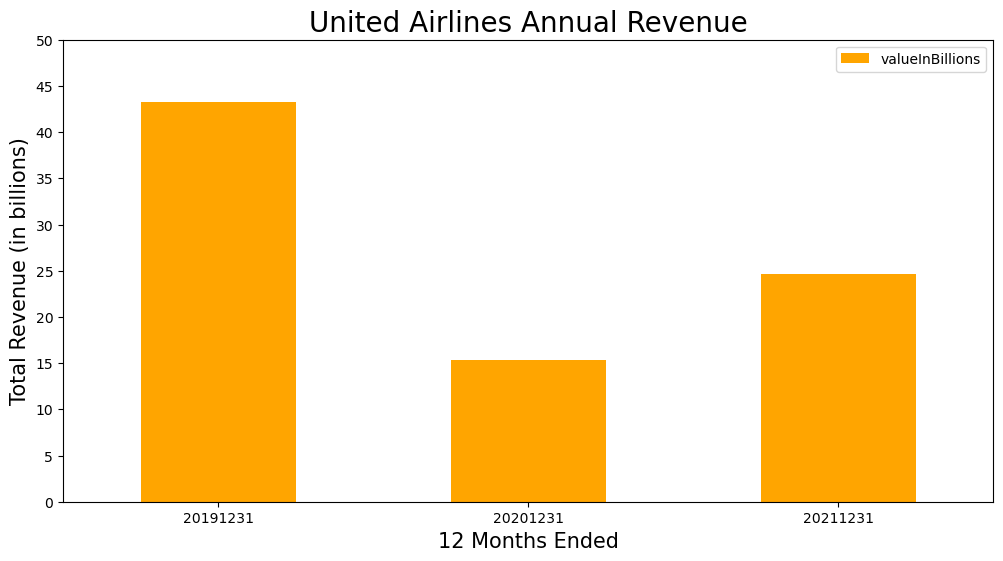

In [10]:
# Create a bar chart with data date (ddate) on x axis and annual revenue (valueInBillions) on y axis
revenueFactsForUnitedAirlines.plot(x='ddate', y='valueInBillions', kind='bar', figsize=(12,6), color='orange')
# Set title and labels for x & y axes
plt.title('United Airlines Annual Revenue',fontsize=20)
plt.xlabel('12 Months Ended', fontsize=15)
plt.ylabel('Total Revenue (in billions)', fontsize=15)
plt.ticklabel_format(axis="y", style="plain")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 51, step=5))
# Save the bar chart as a file in images folder
plt.savefig('images/UnitedAirlinesRevenue.jpg')
plt.show()

### Filter for Annual Revenue of American Airlines and Scale Revenue to Billions

In [11]:
revenueFilterForAmericanAirlines = (joinedFactsAndSubmissionsQ1.name == 'AMERICAN AIRLINES GROUP INC.') \
    & (joinedFactsAndSubmissionsQ1.tag == 'RevenueFromContractWithCustomerExcludingAssessedTax') \
    & (joinedFactsAndSubmissionsQ1.qtrs == 4) \
    & (joinedFactsAndSubmissionsQ1.coreg == 'AmericanAirlinesInc')
revenueFactsForAmerican = joinedFactsAndSubmissionsQ1[revenueFilterForAmericanAirlines][['name', 'tag', 'ddate', 'qtrs', 'uom', 'value']]
revenueFactsForAmerican['valueInBillions'] = revenueFactsForAmerican['value'].apply(lambda x: x/1000000000)
revenueFactsForAmerican = revenueFactsForAmerican.sort_values(by = ['ddate'])
revenueFactsForAmerican

,name,tag,ddate,qtrs,uom,value,valueInBillions
1278765,AMERICAN AIRLINES GROUP INC.,RevenueFromContractWithCustomerExcludingAssess...,20191231,4,USD,45761000000,46
3099706,AMERICAN AIRLINES GROUP INC.,RevenueFromContractWithCustomerExcludingAssess...,20201231,4,USD,17335000000,17
976762,AMERICAN AIRLINES GROUP INC.,RevenueFromContractWithCustomerExcludingAssess...,20211231,4,USD,29880000000,30


### Append American's Revenue DataFrame to United's Revenue DataFrame

In [12]:
revenueFacts = pd.concat([revenueFactsForUnitedAirlines, revenueFactsForAmerican], ignore_index=True).sort_values(by = ['ddate'])
revenueFacts

,name,tag,ddate,qtrs,uom,value,valueInBillions
0,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20191231,4,USD,43259000000,43
3,AMERICAN AIRLINES GROUP INC.,RevenueFromContractWithCustomerExcludingAssess...,20191231,4,USD,45761000000,46
1,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20201231,4,USD,15355000000,15
4,AMERICAN AIRLINES GROUP INC.,RevenueFromContractWithCustomerExcludingAssess...,20201231,4,USD,17335000000,17
2,"UNITED AIRLINES HOLDINGS, INC.",RevenueFromContractWithCustomerExcludingAssess...,20211231,4,USD,24634000000,25
5,AMERICAN AIRLINES GROUP INC.,RevenueFromContractWithCustomerExcludingAssess...,20211231,4,USD,29880000000,30


### Visualize Revenue for Both Airlines

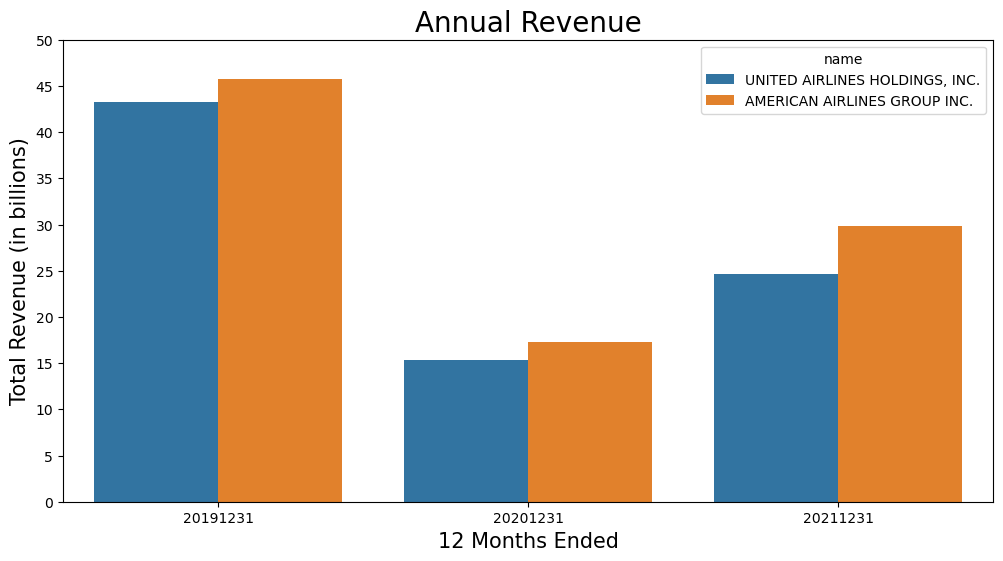

In [13]:
plt.figure(figsize=(12,6))
# Create a bar chart with ddate on x axis and valueInBillions on y axis. The hue parameter is set to filer name for color encoding
sns.barplot(x="ddate", y="valueInBillions", hue="name", data=revenueFacts)
# Set title and labels for x & y axes
plt.title('Annual Revenue',fontsize=20)
plt.xlabel('12 Months Ended', fontsize=15)
plt.ylabel('Total Revenue (in billions)', fontsize=15)
plt.ticklabel_format(axis="y", style="plain")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 51, step=5))
# Save the bar chart as a file in images folder
plt.savefig('images/RevenueBenchmarking.jpg')
plt.show()

### Filter for Income Tax for Both Airlines using IncomeTaxExpenseBenefit tag

In [14]:
taxFilterForUnitedAirlines = (joinedFactsAndSubmissionsQ1.name == 'UNITED AIRLINES HOLDINGS, INC.') \
    & (joinedFactsAndSubmissionsQ1.tag == 'IncomeTaxExpenseBenefit') \
    & (joinedFactsAndSubmissionsQ1.qtrs == 4) \
    & (joinedFactsAndSubmissionsQ1.coreg == 'UnitedAirLinesInc')
taxFactsForUnitedAirlines = joinedFactsAndSubmissionsQ1[taxFilterForUnitedAirlines][['name', 'qtrs', 'ddate', 'uom', 'value']]
taxFactsForUnitedAirlines['valueInMillions'] = taxFactsForUnitedAirlines['value'].apply(lambda x: x/1000000)
taxFilterForAmericanAirlines = (joinedFactsAndSubmissionsQ1.name == 'AMERICAN AIRLINES GROUP INC.') \
    & (joinedFactsAndSubmissionsQ1.tag == 'IncomeTaxExpenseBenefit') \
    & (joinedFactsAndSubmissionsQ1.qtrs == 4) \
    & (joinedFactsAndSubmissionsQ1.coreg == 'AmericanAirlinesInc')
taxFactsForAmerican = joinedFactsAndSubmissionsQ1[taxFilterForAmericanAirlines][['name', 'qtrs', 'ddate', 'uom', 'value']]
taxFactsForAmerican['valueInMillions'] = taxFactsForAmerican['value'].apply(lambda x: x/1000000)
taxFacts = pd.concat([taxFactsForUnitedAirlines, taxFactsForAmerican], ignore_index=True).sort_values(by = ['ddate'])
taxFacts

,name,qtrs,ddate,uom,value,valueInMillions
2,"UNITED AIRLINES HOLDINGS, INC.",4,20191231,USD,905000000,905
5,AMERICAN AIRLINES GROUP INC.,4,20191231,USD,633000000,633
1,"UNITED AIRLINES HOLDINGS, INC.",4,20201231,USD,-1753000000,-1753
3,AMERICAN AIRLINES GROUP INC.,4,20201231,USD,-2453000000,-2453
0,"UNITED AIRLINES HOLDINGS, INC.",4,20211231,USD,-593000000,-593
4,AMERICAN AIRLINES GROUP INC.,4,20211231,USD,-500000000,-500


### Visualize Income Tax for Both Airlines

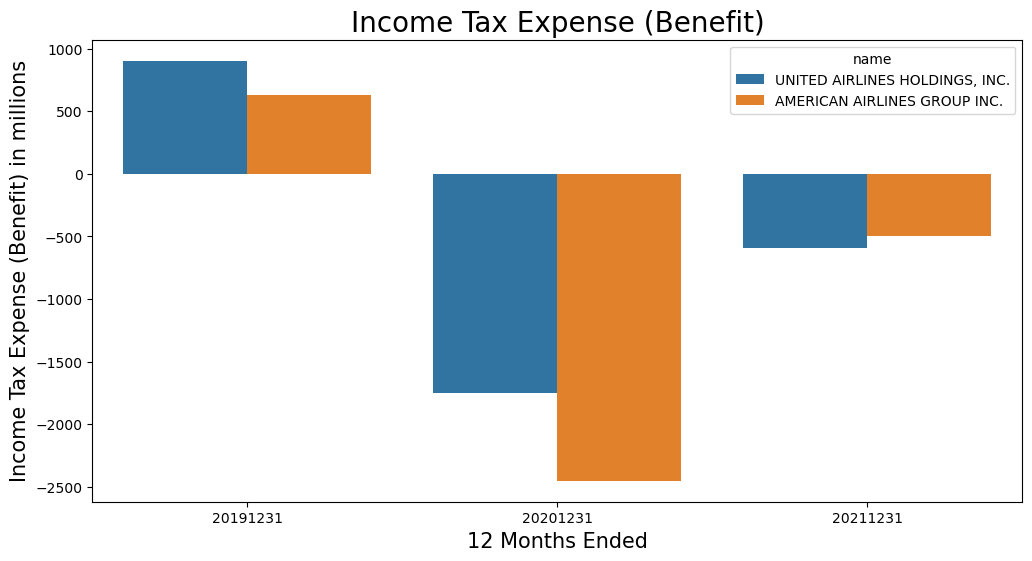

In [15]:
plt.figure(figsize=(12,6))
# Create a bar chart with ddate on x axis and income tax expense (valueInMillions) on y axis. The hue parameter is set to filer name for color encoding
sns.barplot(x="ddate", hue="name", y="valueInMillions", data=taxFacts)
# Set title and labels for x & y axes
plt.title('Income Tax Expense (Benefit)',fontsize=20)
plt.xlabel('12 Months Ended', fontsize=15)
plt.ylabel('Income Tax Expense (Benefit) in millions', fontsize=15)
plt.ticklabel_format(axis="y", style="plain")
plt.xticks(rotation=0)
plt.yticks(np.arange(-2500, 1050, step=500))
# Save the bar chart as a file in images folder
plt.savefig('images/TaxBenchmarking.jpg')
plt.show()